In [3]:
import pandas as pd


file_path = r"D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\cleaned_dataset.xlsx"



# Load the CSV file
df = pd.read_excel(file_path)

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())
print("\n" + "="*50 + "\n")

# Display basic info about the dataset (data types, non-null counts)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50 + "\n")

# Check for missing values (count of NaN per column)
print("Missing Values per Column:")
missing_values = df.isnull().sum()
print(missing_values)
print("\n" + "="*50 + "\n")

# Percentage of missing values per column
print("Percentage of Missing Values per Column:")
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage.round(2))  # Rounded to 2 decimal places
print("\n" + "="*50 + "\n")

# Check column data types and unique value counts (to spot potential errors)
print("Column Data Types and Unique Values:")
for column in df.columns:
    print(f"Column: {column}")
    print(f"  Data Type: {df[column].dtype}")
    print(f"  Unique Values: {df[column].nunique()}")
    # Display sample values (first 5 unique values) to inspect for errors
    print(f"  Sample Values: {df[column].dropna().unique()[:5]}")
    print("-"*30)

First 5 rows of the dataset:
   device  hive number             date  hive temp  hive humidity  \
0       1            5   6/10/2022 0:44      22.79          49.53   
1       2            3   6/10/2022 0:44      21.27          45.40   
2       1            5   6/10/2022 1:43      22.27          50.36   
3       2            3   6/10/2022 1:43      20.54          45.69   
4       1            5  6/10/2022 10:37      38.47          26.42   

   weather temp  weather humidity                   file name  queen presence  \
0         18.21                67  2022-06-10--00-44-04_1.raw               1   
1         18.21                67  2022-06-10--00-44-16_2.raw               1   
2         17.56                69  2022-06-10--01-43-17_1.raw               1   
3         17.56                69  2022-06-10--01-43-29_2.raw               1   
4         29.85                41  2022-06-10--10-37-28_1.raw               1   

   queen acceptance  frames   time  target  
0                 1     


🔍 Analyzing relationships with target: queen presence

📊 Correlation with numeric features:
queen presence      1.000000
queen acceptance    0.827145
weather humidity    0.024738
hive humidity       0.024321
hive temp          -0.049843
weather temp       -0.056772
Name: queen presence, dtype: float64


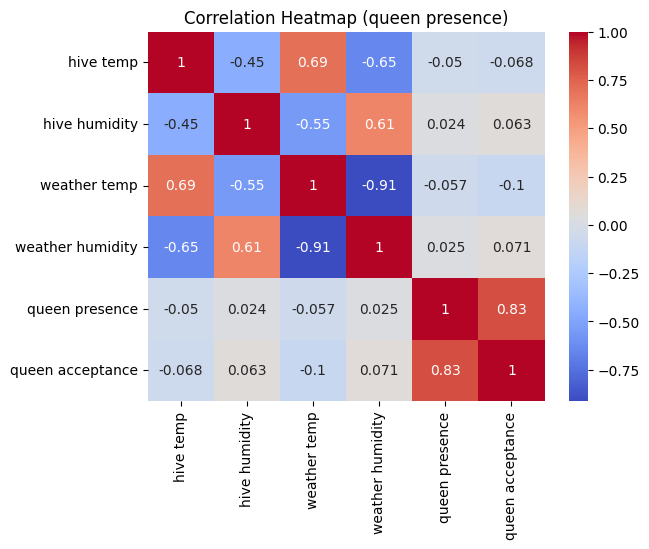


📈 Chi-squared Test Results:
hive temp: chi2 = 0.38, p = 0.5397
hive humidity: chi2 = 0.08, p = 0.7840
weather temp: chi2 = 0.52, p = 0.4690
weather humidity: chi2 = 0.07, p = 0.7895
queen acceptance: chi2 = 138.77, p = 0.0000

🌲 Feature Importances (Random Forest):
queen acceptance    0.914112
weather humidity    0.036242
weather temp        0.023005
hive temp           0.016044
hive humidity       0.010597
dtype: float64


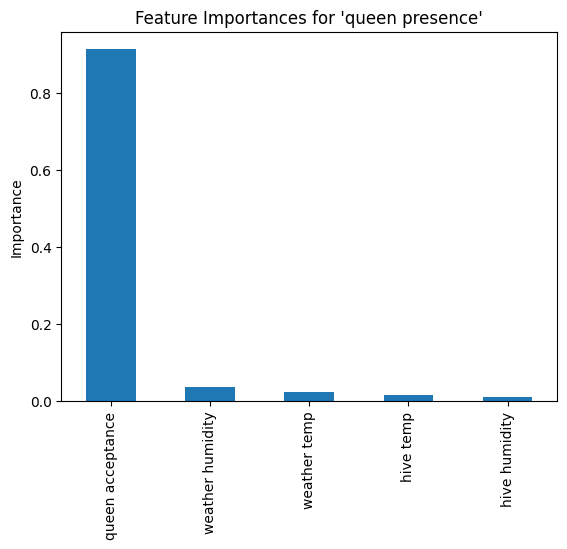


🔍 Analyzing relationships with target: queen acceptance

📊 Correlation matrix not shown for multi-class target.

📈 Chi-squared Test Results:
hive temp: chi2 = 0.73, p = 0.6941
hive humidity: chi2 = 0.83, p = 0.6600
weather temp: chi2 = 2.09, p = 0.3513
weather humidity: chi2 = 1.03, p = 0.5986
queen presence: chi2 = 158.00, p = 0.0000

🌲 Feature Importances (Random Forest):
queen presence      0.668735
hive humidity       0.099956
weather temp        0.085711
hive temp           0.073295
weather humidity    0.072303
dtype: float64


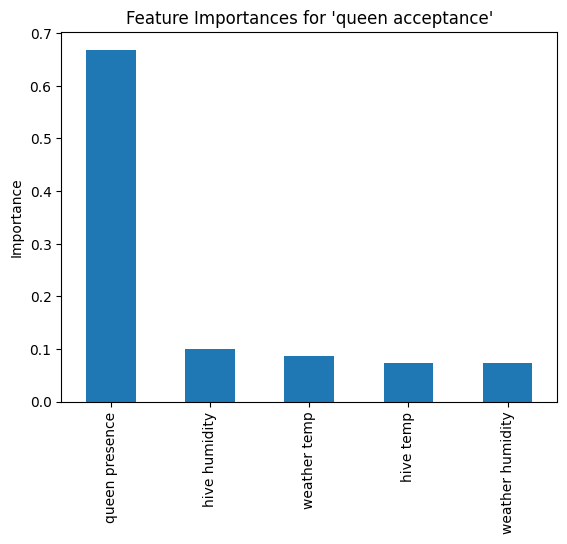

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split


# Drop columns not useful for modeling
df_clean = df.drop(columns=['file name', 'date', 'target', 'device',  'hive number', 'frames', 'time'])

# Normalize numeric columns for chi2
scaler = MinMaxScaler()
df_scaled = df_clean.copy()
df_scaled[df_scaled.columns] = scaler.fit_transform(df_clean[df_clean.columns])

# Function to analyze a target variable
def analyze_target_relationships(target_col):
    print(f"\n🔍 Analyzing relationships with target: {target_col}\n")

    # 1. Correlation (for numeric features)
    if df_clean[target_col].nunique() > 2:
        # For multi-class target, skip correlation
        print("📊 Correlation matrix not shown for multi-class target.")
    else:
        print("📊 Correlation with numeric features:")
        corr = df_clean.corr()[target_col].sort_values(ascending=False)
        print(corr)
        sns.heatmap(df_clean.corr(), annot=True, cmap='coolwarm')
        plt.title(f"Correlation Heatmap ({target_col})")
        plt.show()

    # 2. Chi-squared test (categorical vs categorical)
    print("\n📈 Chi-squared Test Results:")
    X_cat = df_scaled.drop(columns=[target_col])
    y_cat = df_clean[target_col]
    chi_vals, p_vals = chi2(X_cat, y_cat)
    for feature, score, p in zip(X_cat.columns, chi_vals, p_vals):
        print(f"{feature}: chi2 = {score:.2f}, p = {p:.4f}")

    # 3. Feature importance via Random Forest
    print("\n🌲 Feature Importances (Random Forest):")
    X = df_clean.drop(columns=[target_col])
    y = df_clean[target_col]

    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
    model = RandomForestClassifier(n_estimators=50, max_depth=5)
    model.fit(X_train, y_train)
    importances = pd.Series(model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False)
    print(importances)

    # Plot feature importance
    importances.plot(kind="bar", title=f"Feature Importances for '{target_col}'")
    plt.ylabel("Importance")
    plt.show()


# Analyze each of your targets
analyze_target_relationships("queen presence")
analyze_target_relationships("queen acceptance")



🔍 Class distribution for: queen presence
queen presence
1    1064
0     158
Name: count, dtype: int64


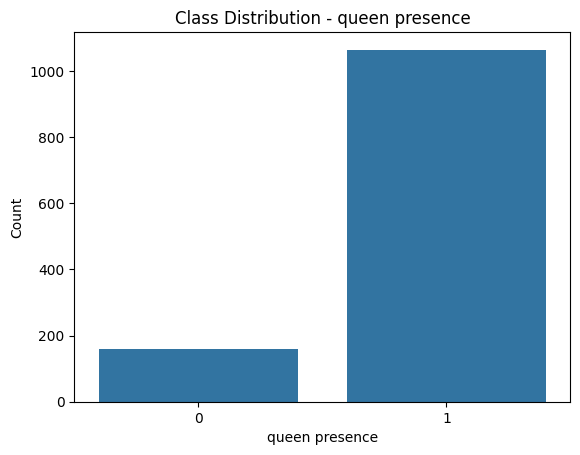


🔍 Class distribution for: queen acceptance
queen acceptance
2    805
1    259
0    158
Name: count, dtype: int64


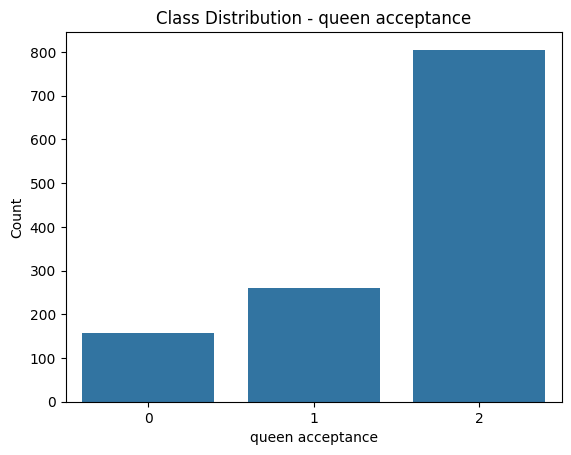

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of your target columns
target_columns = ["queen presence", "queen acceptance"]

for col in target_columns:
    print(f"\n🔍 Class distribution for: {col}")
    print(df[col].value_counts())

    # Plot the class distribution
    sns.countplot(data=df, x=col)
    plt.title(f"Class Distribution - {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


In [8]:
import os
import librosa
import numpy as np
import pandas as pd

# Load dataset
df.columns = df.columns.str.strip()

# Path to the directory containing audio files
audio_dir = r"D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files"

# Function to extract audio features (e.g., MFCCs)
def extract_audio_features(file_path, n_mfcc=13):
    y, sr = librosa.load(file_path, sr=22050)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    return mfccs_mean

# Loop over each file and extract features
audio_features = []
failed_files = []

for fname in df['file name']:
    segment_features = []
    base_name = fname.replace(".raw", "")
    
    try:
        for i in range(6):  # segment0 to segment5
            segment_path = os.path.join(audio_dir, f"{base_name}__segment{i}.wav")
            if os.path.exists(segment_path):
                features = extract_audio_features(segment_path)
                segment_features.append(features)
            else:
                print(f"Segment missing: {segment_path}")

        if segment_features:
            # Average features across segments
            avg_features = np.mean(segment_features, axis=0)
            audio_features.append(avg_features)
        else:
            # If no segment was found or all failed
            audio_features.append([np.nan] * 13)
            failed_files.append(fname)

    except Exception as e:
        print(f"❌ Error processing {fname}: {e}")
        audio_features.append([np.nan] * 13)
        failed_files.append(fname)


# Add audio features to dataframe
mfcc_df = pd.DataFrame(audio_features, columns=[f"mfcc_{i+1}" for i in range(13)])
df_combined = pd.concat([df, mfcc_df], axis=1).dropna()


Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-12--22-58-10_2__segment5.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-14--20-15-04_2__segment5.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-14--22-14-39_2__segment1.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-14--22-14-39_2__segment2.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-14--22-14-39_2__segment3.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-14--22-14-39_2__segment4.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive Condition Projecct\archive\sound_files\sound_files\2022-06-14--22-14-39_2__segment5.wav
Segment missing: D:\AIDS\3rd year\sem2\Bee Hive 

In [9]:
print(df_combined)

      device  hive number             date  hive temp  hive humidity  \
0          1            5   6/10/2022 0:44      22.79          49.53   
1          2            3   6/10/2022 0:44      21.27          45.40   
2          1            5   6/10/2022 1:43      22.27          50.36   
3          2            3   6/10/2022 1:43      20.54          45.69   
4          1            5  6/10/2022 10:37      38.47          26.42   
...      ...          ...              ...        ...            ...   
1217       2            1    7/9/2022 7:57      29.22          43.75   
1218       1            4    7/9/2022 8:34      27.40          74.66   
1219       2            1    7/9/2022 8:57      37.87          32.38   
1220       1            4    7/9/2022 9:34      30.21          65.67   
1221       2            1    7/9/2022 9:56      44.91          24.96   

      weather temp  weather humidity                   file name  \
0            18.21                67  2022-06-10--00-44-04_1.raw   

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Drop non-numeric/unnecessary for model inputs
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])
y = df_combined["queen presence"]  # or "queen acceptance", etc.

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use a simple model (can be replaced with LightGBM or others)
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.65      0.42      0.51        36
           1       0.91      0.96      0.93       209

    accuracy                           0.88       245
   macro avg       0.78      0.69      0.72       245
weighted avg       0.87      0.88      0.87       245



In [11]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# Drop non-numeric/unnecessary for model inputs
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])
y = df_combined["queen acceptance"]  # or "queen acceptance", etc.

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Use a simple model (can be replaced with LightGBM or others)
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.69      0.60        36
           1       0.68      0.47      0.56        53
           2       0.84      0.87      0.85       156

    accuracy                           0.76       245
   macro avg       0.68      0.68      0.67       245
weighted avg       0.76      0.76      0.75       245



In [ ]:
print(X)

      hive temp  hive humidity  weather temp  weather humidity  frames   time  \
0         22.79          49.53         18.21                67       8  0.000   
1         21.27          45.40         18.21                67      10  0.000   
2         22.27          50.36         17.56                69       8  0.042   
3         20.54          45.69         17.56                69      10  0.042   
4         38.47          26.42         29.85                41       8  0.417   
...         ...            ...           ...               ...     ...    ...   
1217      29.22          43.75         15.91                82      10  0.292   
1218      27.40          74.66         17.63                78       8  0.333   
1219      37.87          32.38         18.65                75      10  0.333   
1220      30.21          65.67         20.35                70       8  0.375   
1221      44.91          24.96         21.32                66      10  0.375   

          mfcc_1      mfcc_


📌 Evaluating Model for: Queen Acceptance

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.69      0.60        36
           1       0.68      0.47      0.56        53
           2       0.84      0.87      0.85       156

    accuracy                           0.76       245
   macro avg       0.68      0.68      0.67       245
weighted avg       0.76      0.76      0.75       245



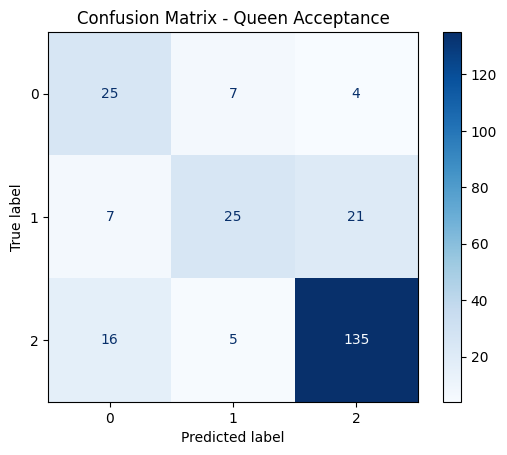


📌 Evaluating Model for: Queen Presence

🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.36      0.46        36
           1       0.90      0.96      0.93       209

    accuracy                           0.87       245
   macro avg       0.76      0.66      0.69       245
weighted avg       0.86      0.87      0.86       245



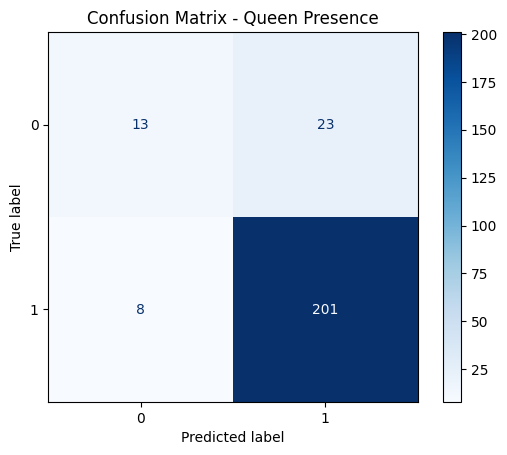

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Shared input features
X = df_combined.drop(columns=["file name", "date", "device", "hive number", "queen presence", "queen acceptance", "target"])

# Define targets
targets = {
    "Queen Acceptance": df_combined["queen acceptance"],
    "Queen Presence": df_combined["queen presence"]
}

for model_name, y in targets.items():
    print(f"\n📌 Evaluating Model for: {model_name}")

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Model
    clf = DecisionTreeClassifier(max_depth=5, random_state=42)
    clf.fit(X_train, y_train)

    # Predict
    y_pred = clf.predict(X_test)

    # Evaluation Report
    print("\n🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()
